### Multiple Linear Regression

#### Problem Statement: 
#### To Predict CO2 Emission

In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import re
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
ALPHA = 0.05 

In [101]:
df = pd.read_csv('../Datasets/co2.csv')

In [102]:
backup = df.copy()

In [103]:
df.shape

(7385, 12)

In [104]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.000,4,AS5,Z,9.900,6.700,8.500,33,196
1,ACURA,ILX,COMPACT,2.400,4,M6,Z,11.200,7.700,9.600,29,221
2,ACURA,ILX HYBRID,COMPACT,1.500,4,AV7,Z,6.000,5.800,5.900,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.500,6,AS6,Z,12.700,9.100,11.100,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.500,6,AS6,Z,12.100,8.700,10.600,27,244


In [105]:
df.sample(5, random_state=RANDOM_STATE)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
7261,PORSCHE,Panamera 4 Executive,FULL-SIZE,3.000,6,AM8,Z,12.400,9.000,10.900,26,253
4489,BMW,M6 CABRIOLET,SUBCOMPACT,4.400,8,AM7,Z,17.300,11.600,14.700,19,344
1539,GMC,SIERRA,PICKUP TRUCK - STANDARD,6.200,8,A8,Z,16.100,11.400,14.000,20,322
3532,CHEVROLET,SILVERADO,PICKUP TRUCK - STANDARD,5.300,8,A6,X,14.600,10.300,12.700,22,297
6418,TOYOTA,4Runner 4WD,SUV - STANDARD,4.000,6,AS5,X,14.300,11.900,13.200,21,308


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [107]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,7385,42,FORD,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,7385,2053,F-150 FFV,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,7385,16,SUV - SMALL,1217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),7385.000,NaN,NaN,NaN,3.160,1.354,0.900,2.000,3.000,3.700,8.400
Cylinders,7385.000,NaN,NaN,NaN,5.615,1.828,3.000,4.000,6.000,6.000,16.000
Transmission,7385,27,AS6,1324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,7385,5,X,3637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),7385.000,NaN,NaN,NaN,12.557,3.500,4.200,10.100,12.100,14.600,30.600
Fuel Consumption Hwy (L/100 km),7385.000,NaN,NaN,NaN,9.042,2.224,4.000,7.500,8.700,10.200,20.600
Fuel Consumption Comb (L/100 km),7385.000,NaN,NaN,NaN,10.975,2.893,4.100,8.900,10.600,12.600,26.100


In [108]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),7385.000,3.160,1.354,0.900,2.000,3.000,3.700,8.400
Cylinders,7385.000,5.615,1.828,3.000,4.000,6.000,6.000,16.000
Fuel Consumption City (L/100 km),7385.000,12.557,3.500,4.200,10.100,12.100,14.600,30.600
Fuel Consumption Hwy (L/100 km),7385.000,9.042,2.224,4.000,7.500,8.700,10.200,20.600
Fuel Consumption Comb (L/100 km),7385.000,10.975,2.893,4.100,8.900,10.600,12.600,26.100
Fuel Consumption Comb (mpg),7385.000,27.482,7.232,11.000,22.000,27.000,32.000,69.000
CO2 Emissions(g/km),7385.000,250.585,58.513,96.000,208.000,246.000,288.000,522.000


In [109]:
df.describe(include='object').T

,count,unique,top,freq
Make,7385,42,FORD,628
Model,7385,2053,F-150 FFV,32
Vehicle Class,7385,16,SUV - SMALL,1217
Transmission,7385,27,AS6,1324
Fuel Type,7385,5,X,3637


In [110]:
pd.DataFrame({
    'dtype': df.dtypes,
    'missing_values': df.isnull().sum(),
    'missing_%' : (df.isnull().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique()
})

,dtype,missing_values,missing_%,unique_values
Make,object,0,0.000,42
Model,object,0,0.000,2053
Vehicle Class,object,0,0.000,16
Engine Size(L),float64,0,0.000,51
Cylinders,int64,0,0.000,8
Transmission,object,0,0.000,27
Fuel Type,object,0,0.000,5
Fuel Consumption City (L/100 km),float64,0,0.000,211
Fuel Consumption Hwy (L/100 km),float64,0,0.000,143
Fuel Consumption Comb (L/100 km),float64,0,0.000,181


In [111]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  1103


In [112]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
duplicate_rows.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
3313,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.400,6.800,8.200,34,192
4371,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.400,6.800,8.200,34,192
5454,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.900,7.000,8.600,33,199
6503,ACURA,ILX,COMPACT,2.400,4,AM8,Z,9.900,7.000,8.600,33,199
3316,ACURA,MDX HYBRID AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
4374,ACURA,MDX HYBRID AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
5457,ACURA,MDX Hybrid AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
6506,ACURA,MDX Hybrid AWD,SUV - SMALL,3.000,6,AM7,Z,9.100,9.000,9.000,31,210
3314,ACURA,MDX SH-AWD,SUV - SMALL,3.500,6,AS9,Z,12.600,9.000,11.000,26,259
4372,ACURA,MDX SH-AWD,SUV - SMALL,3.500,6,AS9,Z,12.600,9.000,11.000,26,259


In [113]:
df[df.duplicated(keep=False)].value_counts()

Make      Model          Vehicle Class          Engine Size(L)  Cylinders  Transmission  Fuel Type  Fuel Consumption City (L/100 km)  Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  Fuel Consumption Comb (mpg)  CO2 Emissions(g/km)
LEXUS     GS F           COMPACT                5.000           8          AS8           Z          14.900                            9.700                            12.500                            23                           293                    5
CHRYSLER  300 AWD        FULL-SIZE              3.600           6          A8            X          12.800                            8.700                            11.000                            26                           258                    4
FIAT      500L           STATION WAGON - SMALL  1.400           4          A6            X          10.700                            7.900                            9.400                             30                           221       

In [114]:
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [115]:
df.shape

(6282, 12)

In [116]:
print("Duplicate Rows: ", df.duplicated().sum()) 

Duplicate Rows:  0


In [117]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Make,6282,42,FORD,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,6282,2053,F-150 FFV,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Class,6282,16,SUV - SMALL,1006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine Size(L),6282.000,NaN,NaN,NaN,3.162,1.365,0.900,2.000,3.000,3.700,8.400
Cylinders,6282.000,NaN,NaN,NaN,5.619,1.846,3.000,4.000,6.000,6.000,16.000
Transmission,6282,27,AS6,1139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Type,6282,5,X,3039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fuel Consumption City (L/100 km),6282.000,NaN,NaN,NaN,12.610,3.553,4.200,10.100,12.100,14.700,30.600
Fuel Consumption Hwy (L/100 km),6282.000,NaN,NaN,NaN,9.071,2.279,4.000,7.500,8.700,10.300,20.600
Fuel Consumption Comb (L/100 km),6282.000,NaN,NaN,NaN,11.018,2.947,4.100,8.900,10.600,12.700,26.100


In [118]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

print(f"We have {len(categorical_features)} categoriacal features: {categorical_features}")
print()
print(f"We have {len(numerical_features)} numerical features: {numerical_features}")

We have 5 categoriacal features: ['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

We have 7 numerical features: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']


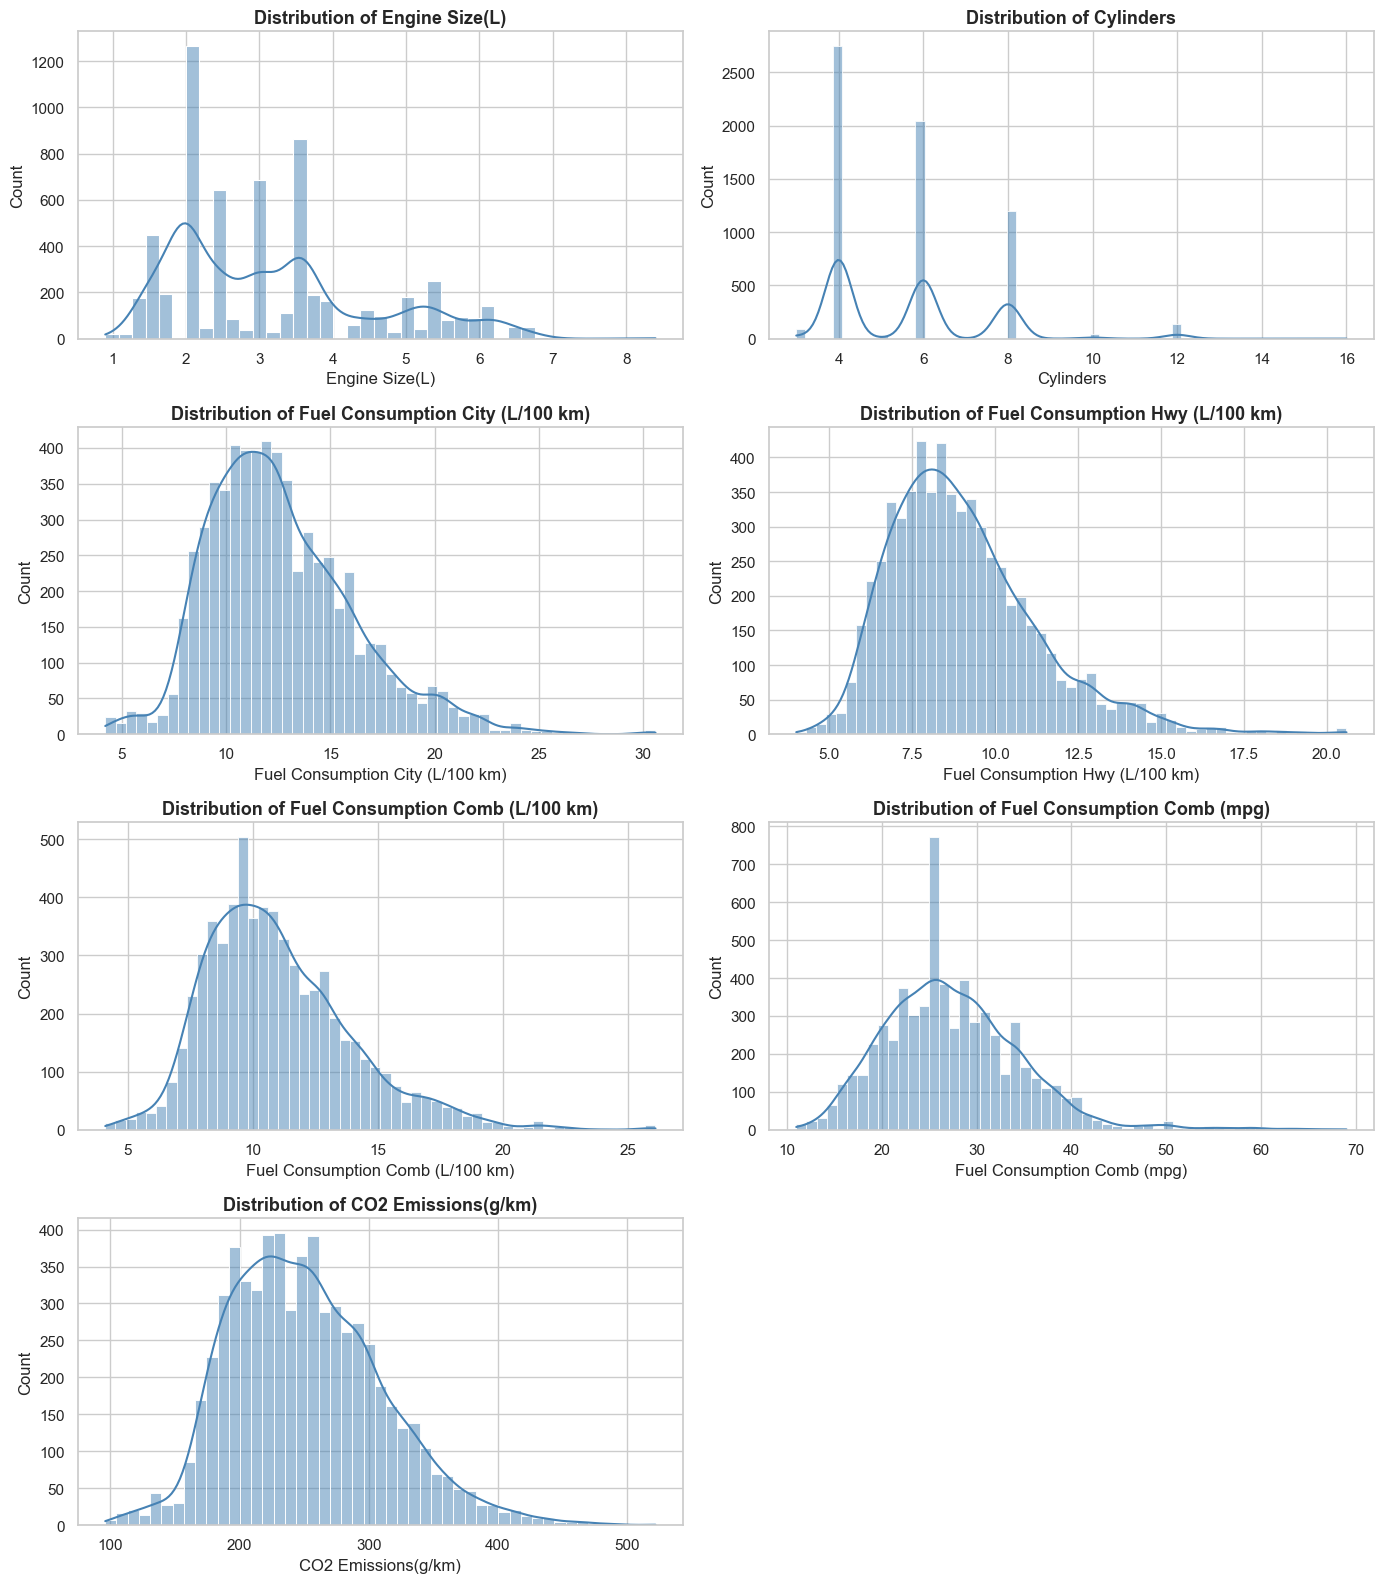

In [119]:
fig, axes = plt.subplots(nrows=(len(numerical_features)+1)//2, ncols=2, figsize=(14, 4*((len(numerical_features)+1)//2)))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [120]:
df[numerical_features].skew().sort_values(ascending=False).to_frame('Skewness')

,Skewness
Fuel Consumption Hwy (L/100 km),1.109
Cylinders,1.108
Fuel Consumption Comb (L/100 km),0.924
Fuel Consumption Comb (mpg),0.923
Fuel Consumption City (L/100 km),0.839
Engine Size(L),0.812
CO2 Emissions(g/km),0.556


- Every Numerical Feature is Right Skewed

In [121]:
for col in categorical_features:
    print(f"\n--- {col} (top 10) ---")
    print(df[col].value_counts().head(10))


--- Make (top 10) ---
Make
FORD             577
CHEVROLET        515
BMW              501
MERCEDES-BENZ    365
PORSCHE          296
GMC              289
TOYOTA           276
AUDI             263
NISSAN           213
JEEP             200
Name: count, dtype: int64

--- Model (top 10) ---
Model
F-150 FFV        32
F-150 FFV 4X4    31
MUSTANG          27
FOCUS FFV        24
F-150 4X4        20
F-150            19
SONIC 5          18
ATS              18
COMPASS          18
JETTA            18
Name: count, dtype: int64

--- Vehicle Class (top 10) ---
Vehicle Class
SUV - SMALL                1006
MID-SIZE                    983
COMPACT                     903
SUV - STANDARD              613
SUBCOMPACT                  533
FULL-SIZE                   508
PICKUP TRUCK - STANDARD     475
TWO-SEATER                  381
MINICOMPACT                 274
STATION WAGON - SMALL       214
Name: count, dtype: int64

--- Transmission (top 10) ---
Transmission
AS6    1139
AS8    1056
M6      773
A6      

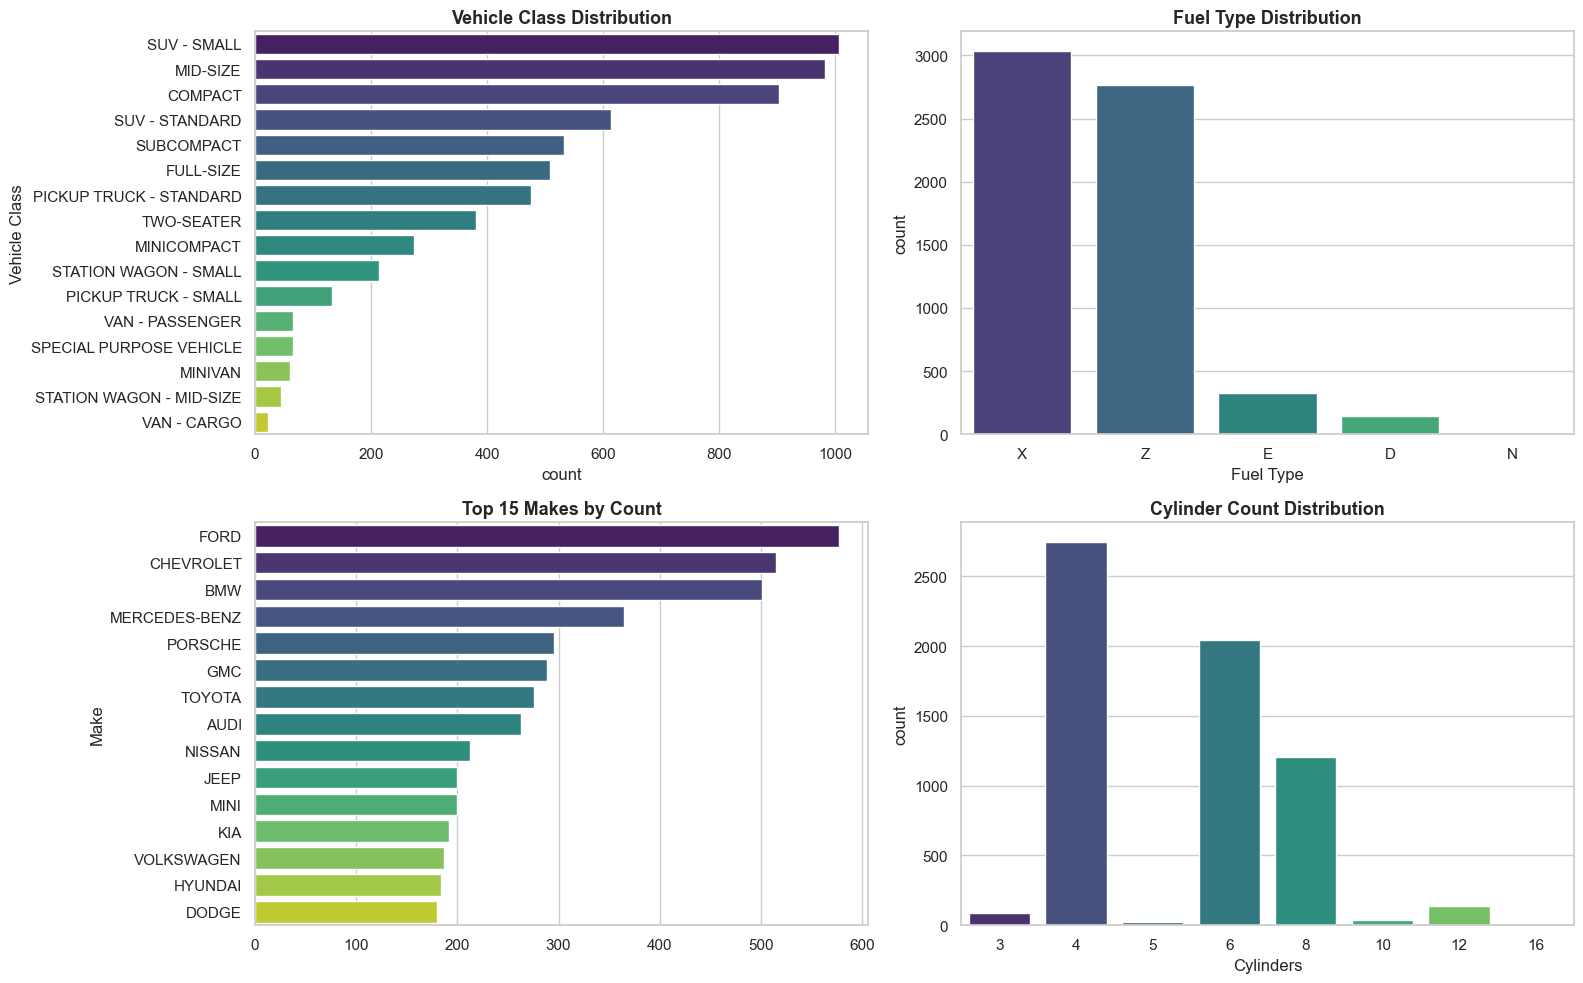

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

sns.countplot(y='Vehicle Class', data=df, order=df['Vehicle Class'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Vehicle Class Distribution')

sns.countplot(x='Fuel Type', data=df, order=df['Fuel Type'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Fuel Type Distribution')

top_makes = df['Make'].value_counts().head(15)
sns.barplot(y=top_makes.index, x=top_makes.values, ax=axes[2], palette='viridis')
axes[2].set_title('Top 15 Makes by Count')

sns.countplot(x='Cylinders', data=df, order=sorted(df['Cylinders'].unique()), ax=axes[3], palette='viridis')
axes[3].set_title('Cylinder Count Distribution')

plt.tight_layout()
plt.show()


#### Outlier Detection
##### Using the interquartile range (IQR) rule: any value beyond `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR` is flagged as a potential outlier.

In [123]:
def iqr_outlier_summary(df, cols):
    summary = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        summary.append({'Feature': col, 'Lower Bound': round(lower,2), 'Upper Bound': round(upper,2),
                         'Outlier Count': n_outliers, 'Outlier %': round(100*n_outliers/len(df), 2)})
    return pd.DataFrame(summary)

iqr_outlier_summary(df, numerical_features)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Engine Size(L),-0.550,6.250,121,1.930
1,Cylinders,1.000,9.000,177,2.820
2,Fuel Consumption City (L/100 km),3.200,21.600,116,1.850
3,Fuel Consumption Hwy (L/100 km),3.300,14.500,150,2.390
4,Fuel Consumption Comb (L/100 km),3.200,18.400,115,1.830
5,Fuel Consumption Comb (mpg),7.000,47.000,95,1.510
6,CO2 Emissions(g/km),86.500,410.500,74,1.180


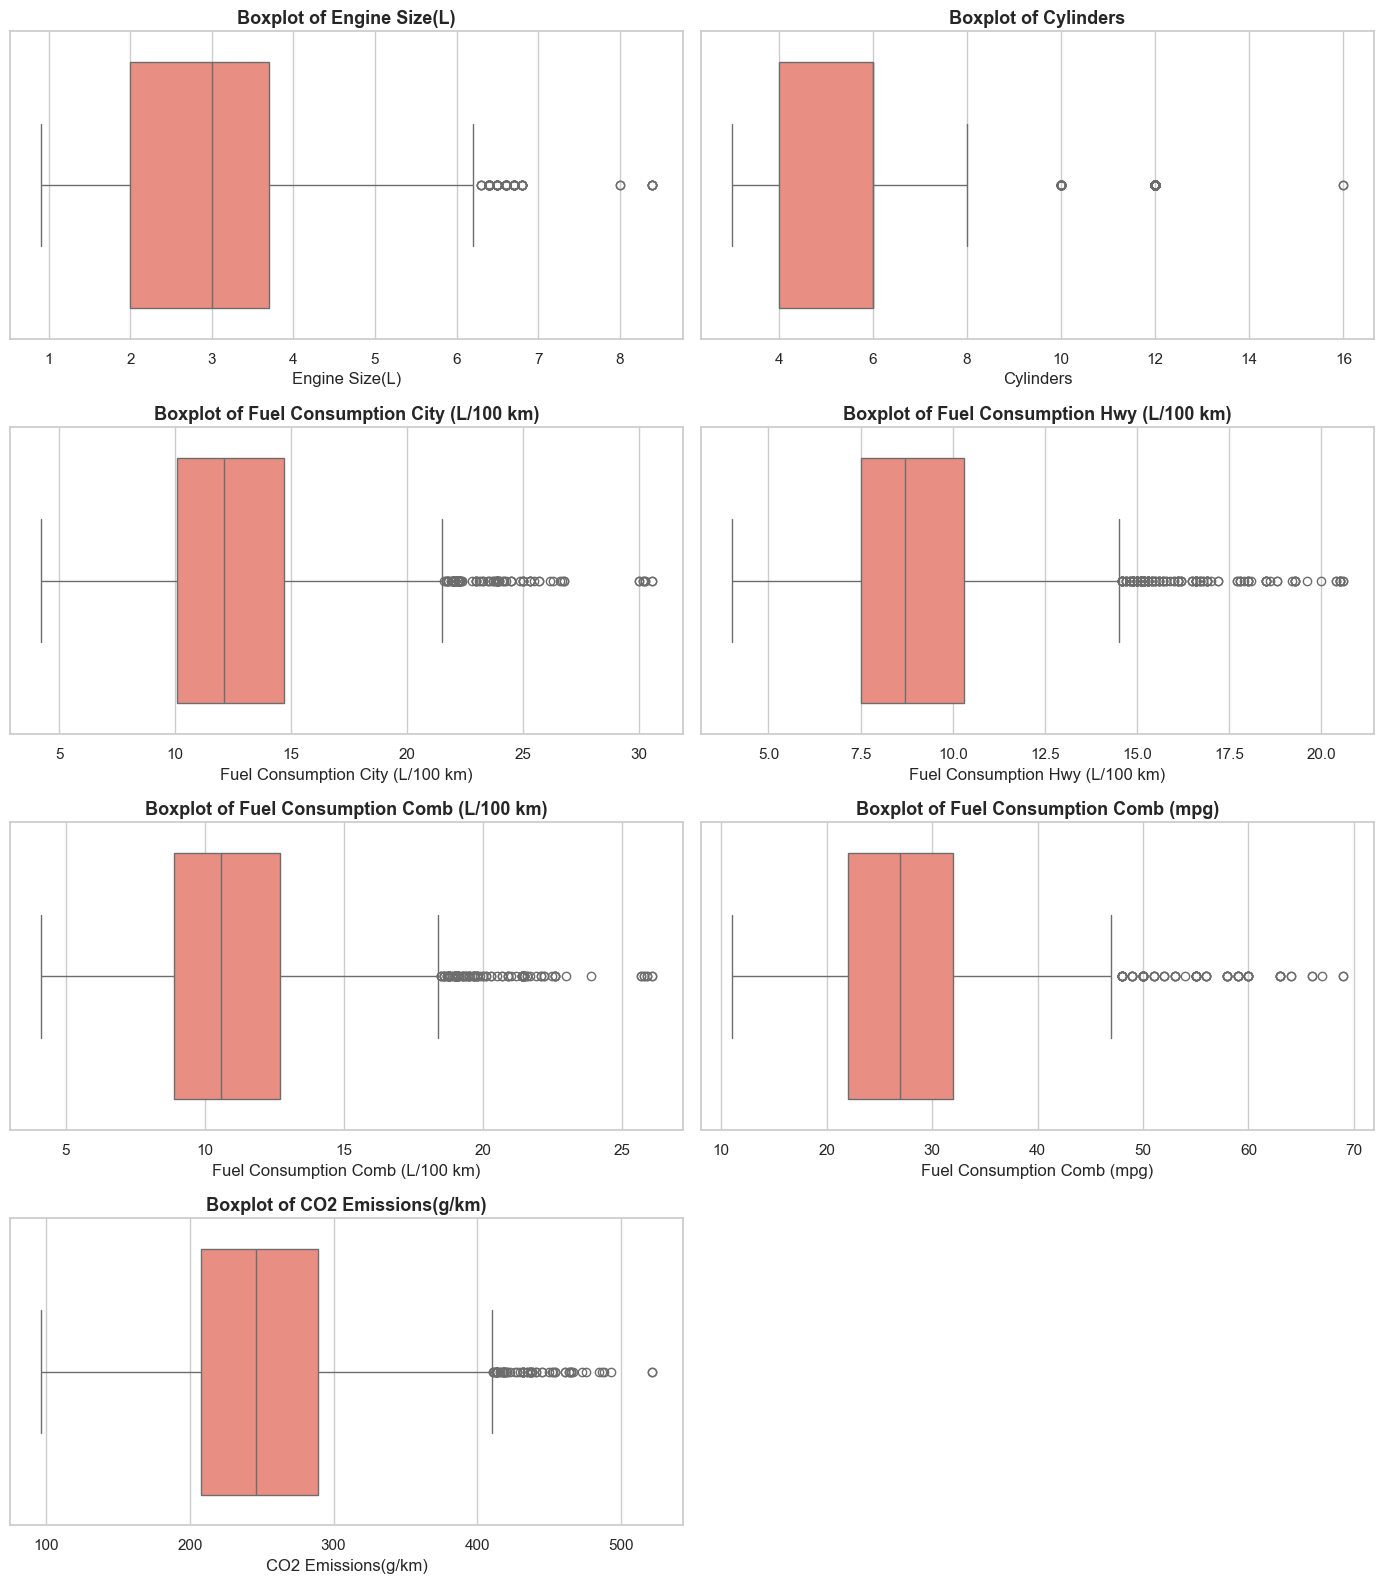

In [124]:
fig, axes = plt.subplots(nrows=(len(numerical_features)+1)//2, ncols=2, figsize=(14, 4*((len(numerical_features)+1)//2)))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'Boxplot of {col}')
for j in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Outliers here (e.g., very high engine size / cylinders / CO2) mostly correspond to genuine high-performance vehicles rather than data errors, so we retain them rather than removing them

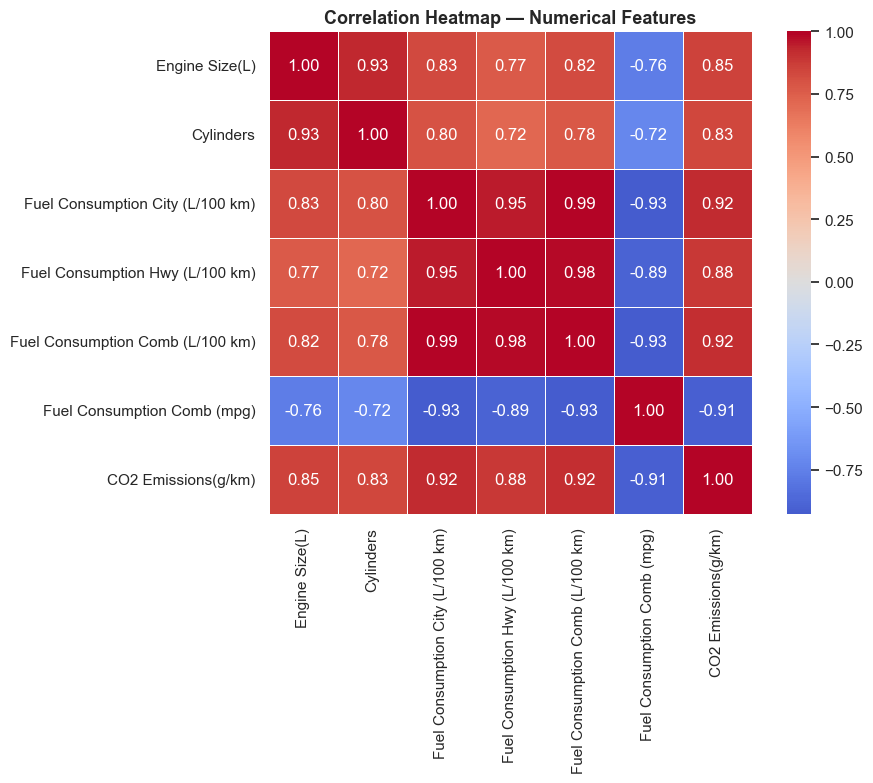

In [125]:
plt.figure(figsize=(10, 8))
corr = df[numerical_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()


In [126]:
corr['CO2 Emissions(g/km)'].sort_values(ascending=False)

CO2 Emissions(g/km)                 1.000
Fuel Consumption City (L/100 km)    0.919
Fuel Consumption Comb (L/100 km)    0.917
Fuel Consumption Hwy (L/100 km)     0.883
Engine Size(L)                      0.855
Cylinders                           0.835
Fuel Consumption Comb (mpg)        -0.907
Name: CO2 Emissions(g/km), dtype: float64

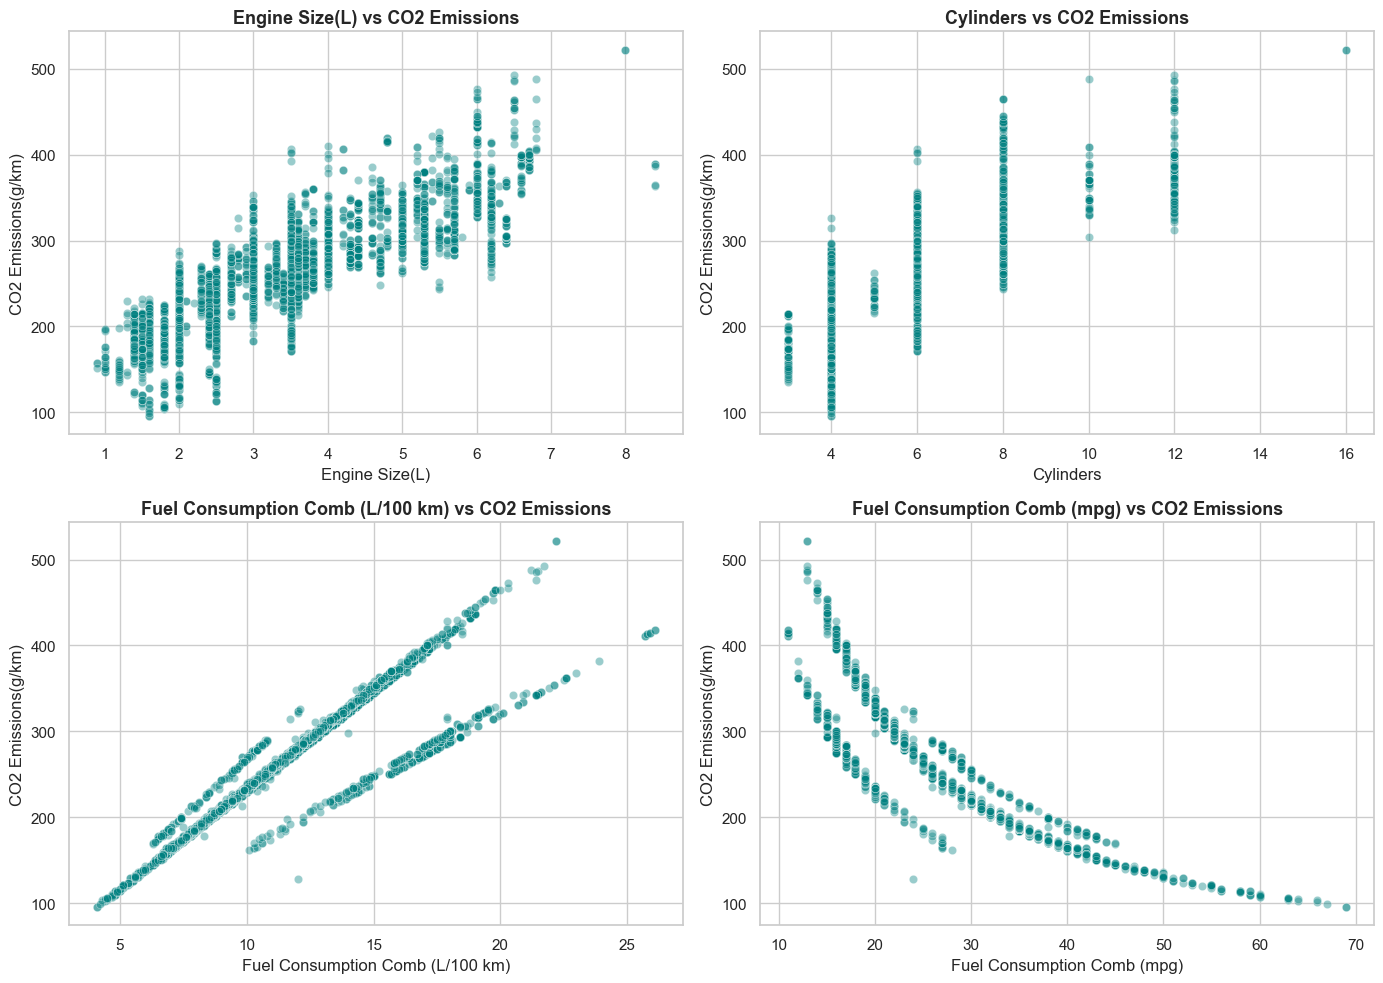

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
scatter_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)']
for i, col in enumerate(scatter_cols):
    sns.scatterplot(x=col, y='CO2 Emissions(g/km)', data=df, alpha=0.4, ax=axes[i], color='teal')
    axes[i].set_title(f'{col} vs CO2 Emissions')
plt.tight_layout()
plt.show()

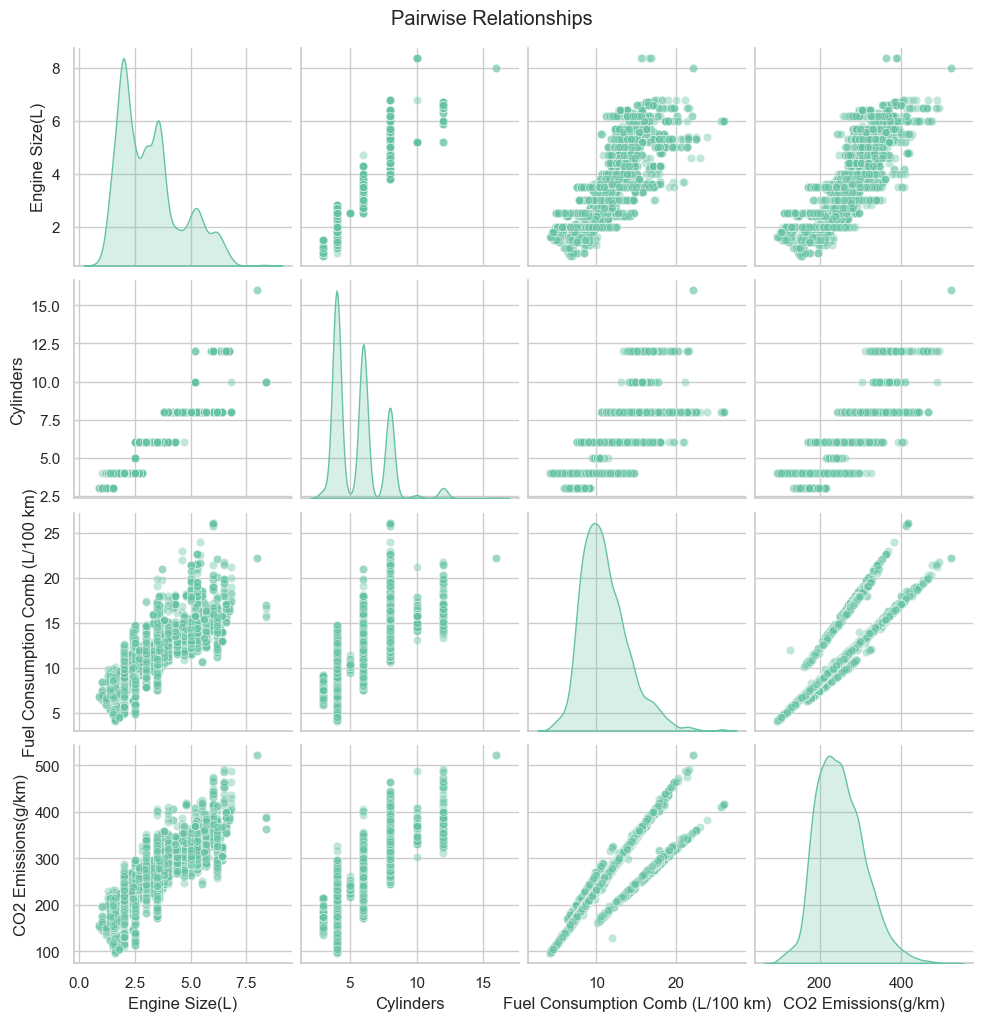

In [128]:
sns.pairplot(df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']],
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

#### Feature Engineering

In [129]:
## Split Transmission into Type + Gears

df['Gears'] = df['Transmission'].str.extract(r'(\d+)$')
df['Gears'] = df['Gears'].astype('Int64')
df['Transmission'] = df['Transmission'].str.replace(r'\d+$', '', regex=True)

print(df['Transmission'].value_counts())
print("\nGears summary:")
print(df['Gears'].describe())
df[['Transmission', 'Gears']].head(10)

Transmission
AS    2722
A     1536
M     1019
AM     540
AV     465
Name: count, dtype: int64

Gears summary:
count   6041.000
mean       6.868
std        1.212
min        4.000
25%        6.000
50%        6.000
75%        8.000
max       10.000
Name: Gears, dtype: Float64


,Transmission,Gears
0,AS,5
1,M,6
2,AV,7
3,AS,6
4,AS,6
5,AS,6
6,AS,6
7,AS,6
8,M,6
9,AS,5


In [130]:
df['City_Hwy_Consumption_Ratio'] = (df['Fuel Consumption City (L/100 km)'] /
                                     df['Fuel Consumption Hwy (L/100 km)']).round(3)
df[['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'City_Hwy_Consumption_Ratio']].head()


,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),City_Hwy_Consumption_Ratio
0,9.900,6.700,1.478
1,11.200,7.700,1.455
2,6.000,5.800,1.034
3,12.700,9.100,1.396
4,12.100,8.700,1.391


In [131]:
df['Engine_Size_per_Cylinder'] = (df['Engine Size(L)'] / df['Cylinders']).round(3)
df[['Engine Size(L)', 'Cylinders', 'Engine_Size_per_Cylinder']].head()


,Engine Size(L),Cylinders,Engine_Size_per_Cylinder
0,2.000,4,0.500
1,2.400,4,0.600
2,1.500,4,0.375
3,3.500,6,0.583
4,3.500,6,0.583


In [132]:
## CO2 Efficiency Score (CO2 emitted per unit of combined fuel consumption)

df['CO2_per_L100km'] = (df['CO2 Emissions(g/km)'] / df['Fuel Consumption Comb (L/100 km)']).round(2)
df[['CO2 Emissions(g/km)', 'Fuel Consumption Comb (L/100 km)', 'CO2_per_L100km']].head()

,CO2 Emissions(g/km),Fuel Consumption Comb (L/100 km),CO2_per_L100km
0,196,8.500,23.060
1,221,9.600,23.020
2,136,5.900,23.050
3,255,11.100,22.970
4,244,10.600,23.020


In [133]:
size_map = {
    'TWO-SEATER': 'Compact/Small', 'MINICOMPACT': 'Compact/Small', 'SUBCOMPACT': 'Compact/Small',
    'COMPACT': 'Compact/Small',
    'MID-SIZE': 'Mid-size', 'FULL-SIZE': 'Mid-size', 'STATION WAGON - SMALL': 'Mid-size',
    'STATION WAGON - MID-SIZE': 'Mid-size',
    'SUV - SMALL': 'SUV', 'SUV - STANDARD': 'SUV',
    'PICKUP TRUCK - SMALL': 'Truck/Van', 'PICKUP TRUCK - STANDARD': 'Truck/Van',
    'MINIVAN': 'Truck/Van', 'VAN - CARGO': 'Truck/Van', 'VAN - PASSENGER': 'Truck/Van',
    'SPECIAL PURPOSE VEHICLE': 'Other'
}
df['Vehicle_Size_Group'] = df['Vehicle Class'].map(size_map)
print(df['Vehicle_Size_Group'].value_counts())
print("\nUnmapped (check for typos):", df[df['Vehicle_Size_Group'].isna()]['Vehicle Class'].unique())

Vehicle_Size_Group
Compact/Small    2091
Mid-size         1750
SUV              1619
Truck/Van         757
Other              65
Name: count, dtype: int64

Unmapped (check for typos): []


In [134]:
fuel_map = {'X': 'Regular Gasoline', 'Z': 'Premium Gasoline', 'D': 'Diesel', 'E': 'Ethanol (E85)', 'N': 'Natural Gas'}
df['Fuel_Type_Label'] = df['Fuel Type'].map(fuel_map)
df[['Fuel Type', 'Fuel_Type_Label']].drop_duplicates()

,Fuel Type,Fuel_Type_Label
0,Z,Premium Gasoline
28,D,Diesel
140,X,Regular Gasoline
145,E,Ethanol (E85)
2232,N,Natural Gas


In [135]:
df.to_csv('../Datasets/co2_cleaned_engineered.csv', index=False)

### Model Training

In [136]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Gears,City_Hwy_Consumption_Ratio,Engine_Size_per_Cylinder,CO2_per_L100km,Vehicle_Size_Group,Fuel_Type_Label
0,ACURA,ILX,COMPACT,2.000,4,AS,Z,9.900,6.700,8.500,33,196,5,1.478,0.500,23.060,Compact/Small,Premium Gasoline
1,ACURA,ILX,COMPACT,2.400,4,M,Z,11.200,7.700,9.600,29,221,6,1.455,0.600,23.020,Compact/Small,Premium Gasoline
2,ACURA,ILX HYBRID,COMPACT,1.500,4,AV,Z,6.000,5.800,5.900,48,136,7,1.034,0.375,23.050,Compact/Small,Premium Gasoline
3,ACURA,MDX 4WD,SUV - SMALL,3.500,6,AS,Z,12.700,9.100,11.100,25,255,6,1.396,0.583,22.970,SUV,Premium Gasoline
4,ACURA,RDX AWD,SUV - SMALL,3.500,6,AS,Z,12.100,8.700,10.600,27,244,6,1.391,0.583,23.020,SUV,Premium Gasoline


**Target:** `CO2 Emissions(g/km)`

**Dropping before modeling:**
- `Make`, `Model` : very high cardinality (400+ unique models); not useful for a plain Linear Regression without heavy target/frequency encoding, and risk overfitting a linear model.
- `Fuel_Type_Label` : this is just the decoded/readable version of `Fuel Type`. Keeping both would be redundant (perfect duplicate information), so we keep the original `Fuel Type` and drop the label.
- `CO2_per_L100km` : **this is a data leakage feature.** It was engineered directly from `CO2 Emissions(g/km) / Fuel Consumption Comb (L/100 km)`, so it mathematically encodes the target. Including it would make the model look artificially perfect while being useless in the real world.
- `Vehicle Class` : we keep the engineered `Vehicle_Size_Group` instead (lower cardinality, same underlying signal), dropping the raw high-cardinality original.

In [137]:
target_col = 'CO2 Emissions(g/km)'

drop_cols = ['Make', 'Model', 'Fuel_Type_Label', 'CO2_per_L100km', 'Vehicle Class']

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("Feature columns used:")
print(X.columns.tolist())
print("\nX shape:", X.shape, "| y shape:", y.shape)

Feature columns used:
['Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'Gears', 'City_Hwy_Consumption_Ratio', 'Engine_Size_per_Cylinder', 'Vehicle_Size_Group']

X shape: (6282, 12) | y shape: (6282,)


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6282 entries, 0 to 6281
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              6282 non-null   object 
 1   Model                             6282 non-null   object 
 2   Vehicle Class                     6282 non-null   object 
 3   Engine Size(L)                    6282 non-null   float64
 4   Cylinders                         6282 non-null   int64  
 5   Transmission                      6282 non-null   object 
 6   Fuel Type                         6282 non-null   object 
 7   Fuel Consumption City (L/100 km)  6282 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   6282 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  6282 non-null   float64
 10  Fuel Consumption Comb (mpg)       6282 non-null   int64  
 11  CO2 Emissions(g/km)               6282 non-null   int64  
 12  Gears 

In [139]:
cat_cols = [feature for feature in X.columns if X[feature].dtype == 'O']
print("Categorical columns to encode:", cat_cols)

# Impute missing Gears  with the median
if X['Gears'].isnull().sum() > 0:
    median_gears = X['Gears'].median()
    print(f"Filling {X['Gears'].isnull().sum()} missing 'Gears' values with median = {median_gears}")
    X['Gears'] = X['Gears'].fillna(median_gears)

X = pd.get_dummies(X, columns=cat_cols, drop_first=True) 
X = X.astype({col: 'int' for col in X.select_dtypes(include='bool').columns})

print("\nEncoded feature shape:", X.shape)
X.head()

Categorical columns to encode: ['Transmission', 'Fuel Type', 'Vehicle_Size_Group']
Filling 241 missing 'Gears' values with median = 6.0

Encoded feature shape: (6282, 21)


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Gears,City_Hwy_Consumption_Ratio,Engine_Size_per_Cylinder,Transmission_AM,Transmission_AS,Transmission_AV,Transmission_M,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Vehicle_Size_Group_Mid-size,Vehicle_Size_Group_Other,Vehicle_Size_Group_SUV,Vehicle_Size_Group_Truck/Van
0,2.000,4,9.900,6.700,8.500,33,5,1.478,0.500,0,1,0,0,0,0,0,1,0,0,0,0
1,2.400,4,11.200,7.700,9.600,29,6,1.455,0.600,0,0,0,1,0,0,0,1,0,0,0,0
2,1.500,4,6.000,5.800,5.900,48,7,1.034,0.375,0,0,1,0,0,0,0,1,0,0,0,0
3,3.500,6,12.700,9.100,11.100,25,6,1.396,0.583,0,1,0,0,0,0,0,1,0,0,1,0
4,3.500,6,12.100,8.700,10.600,27,6,1.391,0.583,0,1,0,0,0,0,0,1,0,0,1,0


In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (5025, 21) | Test shape: (1257, 21)


In [141]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [142]:
X_train_scaled

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Gears,City_Hwy_Consumption_Ratio,Engine_Size_per_Cylinder,Transmission_AM,Transmission_AS,Transmission_AV,Transmission_M,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Vehicle_Size_Group_Mid-size,Vehicle_Size_Group_Other,Vehicle_Size_Group_SUV,Vehicle_Size_Group_Truck/Van
5845,-0.849,-0.874,-0.729,-0.379,-0.612,0.491,0.988,-1.294,-0.522,-0.307,1.140,-0.284,-0.440,-0.235,0.000,-0.975,1.130,-0.617,-0.105,1.695,-0.375
106,0.914,1.305,0.677,0.322,0.574,-0.752,0.988,1.190,0.012,-0.307,-0.877,-0.284,-0.440,-0.235,0.000,-0.975,1.130,-0.617,-0.105,-0.590,-0.375
1426,1.355,1.305,0.649,0.191,0.473,-0.614,-0.686,1.486,0.812,-0.307,1.140,-0.284,-0.440,-0.235,0.000,1.025,-0.885,-0.617,-0.105,-0.590,-0.375
2934,-0.335,0.216,-0.532,-0.729,-0.612,0.491,0.151,0.511,-1.055,3.261,-0.877,-0.284,-0.440,-0.235,0.000,-0.975,1.130,-0.617,-0.105,-0.590,-0.375
1451,2.089,1.305,2.646,2.557,2.642,-1.719,-0.686,0.759,2.145,-0.307,-0.877,-0.284,-0.440,-0.235,0.000,1.025,-0.885,-0.617,-0.105,-0.590,2.665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-0.482,-0.874,-0.842,-0.904,-0.883,0.906,-0.686,-0.088,0.812,-0.307,-0.877,-0.284,2.273,-0.235,0.000,1.025,-0.885,1.620,-0.105,-0.590,-0.375
5191,-1.217,-0.874,-1.179,-1.255,-1.222,1.458,-0.686,-0.216,-1.855,-0.307,-0.877,-0.284,2.273,-0.235,0.000,-0.975,1.130,-0.617,-0.105,-0.590,-0.375
5226,-0.849,-0.874,-0.786,-0.729,-0.781,0.630,-0.686,-0.464,-0.522,-0.307,-0.877,-0.284,2.273,-0.235,0.000,1.025,-0.885,1.620,-0.105,-0.590,-0.375
5390,-0.849,-0.874,-1.067,-0.904,-1.019,1.044,-0.686,-0.999,-0.522,-0.307,-0.877,-0.284,2.273,-0.235,0.000,1.025,-0.885,-0.617,-0.105,-0.590,-0.375


In [143]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained.")
print("Intercept:", round(model.intercept_, 3))


Model trained.
Intercept: 250.806


In [144]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.4f}")
    print()
    return mae, rmse, r2

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_metrics = evaluate(y_train, y_train_pred, "Train Set")
test_metrics = evaluate(y_test, y_test_pred, "Test Set")

--- Train Set ---
MAE  : 2.983
RMSE : 4.882
R2   : 0.9932

--- Test Set ---
MAE  : 3.195
RMSE : 6.030
R2   : 0.9899



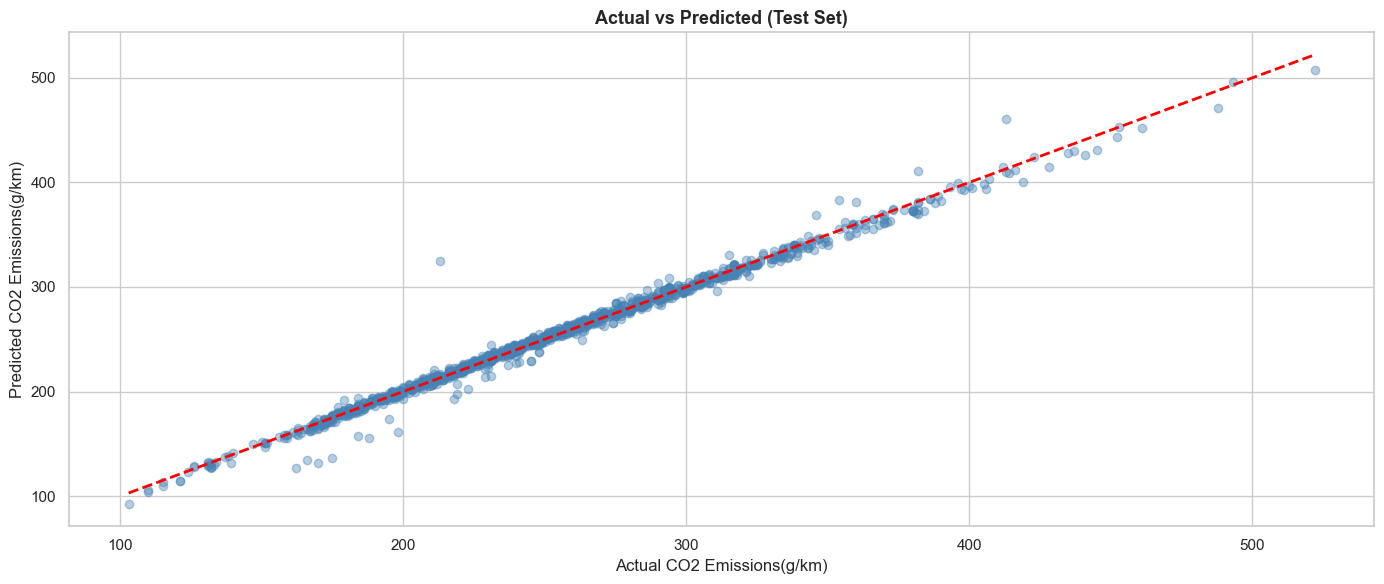

In [145]:
plt.figure(figsize=(14, 6))

plt.scatter(y_test, y_test_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO2 Emissions(g/km)')
plt.ylabel('Predicted CO2 Emissions(g/km)')
plt.title('Actual vs Predicted (Test Set)')


plt.tight_layout()
plt.show()
